<a href="https://colab.research.google.com/github/maschu09/mless/blob/main/remote_sensing/Random_forest_classifier_on_remote_sensing_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random forest classifier for landcover classification from remote sensing images

In this tasks, we will use a portion of the [SAT-6](https://csc.lsu.edu/~saikat/deepsat/) dataset from Louisiana State University and NASA Ames Research Center.

For this demonstration, we only use the test dataset, which consists of 81000 samples randomly distributed across 6 landcover classes.

In [1]:
# Random forest classifier for landcover classification
# Author: Ankit Patnala, JSC, 2025; updated by Martin Schultz, April 2026
# Download necessary packages if right kernel is not present
# Not needed in colab
#!pip install pandas
#!pip install scikit-learn
#!pip install matplotlib

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

## Obtaining the data
The data is available via this B2share link [link](https://b2share.eudat.eu/records/89654eac10724d30a6c7e51f2c5422de). Download all the files at the same folder path where you are creating this notebook

Alternatively use the following wget commands to download the data

The following cell can be executed in Google colab

In [3]:
!mkdir -p data
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/X_test_sat6.csv
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/y_test_sat6.csv
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/sat6annotations.csv
# Note that `cd data`, ..., `cd ..` doesn't work

zsh:1: command not found: wget
zsh:1: command not found: wget
zsh:1: command not found: wget


In [4]:
# load the csv file with the image data. Each row belongs to one sample. Each sample has 3136 columns i.e. 4 channels (R,G,B, and NIR) and 28 \times 28 spatial size
landcover_df = pd.read_csv("./data/X_test_sat6.csv",header=None)
landcover_df

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
0,95,91,61,157,105,113,101,179,50,35,...,107,181,118,137,127,205,90,105,86,183
1,102,102,103,137,108,110,116,154,88,83,...,91,157,95,92,84,143,89,85,76,130
2,47,54,95,10,79,89,108,15,96,131,...,118,17,82,98,125,18,61,69,113,13
3,200,181,178,218,192,177,176,214,162,141,...,139,203,157,138,125,193,147,128,107,187
4,85,101,100,15,87,102,97,16,54,71,...,74,8,37,49,76,6,27,43,69,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80995,82,82,115,17,104,123,131,23,100,119,...,146,32,137,152,159,44,159,166,166,61
80996,170,148,147,174,203,188,163,190,211,197,...,134,172,163,154,136,175,172,157,143,177
80997,140,136,126,190,156,163,152,208,152,170,...,126,162,93,111,119,170,68,66,61,123
80998,89,87,99,13,64,66,89,9,16,26,...,111,15,49,52,97,11,47,56,102,9


&#x1F479;  _Task:_ Make sure you understand this data structure.

&#x1F479;  _Question:_ What would you need to do to extract only the green and the infrared channel from this data?

In [5]:
# Read the annotation file to get the annotation i.e. classname corresponding to the labels
annotations = pd.read_csv("./data/sat6annotations.csv", header=None)
print(annotations)
labels = annotations[0].values
print(f'class labels: {labels}')

             0  1  2  3  4  5  6
0     building  1  0  0  0  0  0
1  barren_land  0  1  0  0  0  0
2        trees  0  0  1  0  0  0
3    grassland  0  0  0  1  0  0
4         road  0  0  0  0  1  0
5        water  0  0  0  0  0  1
class labels: <StringArray>
['building', 'barren_land', 'trees', 'grassland', 'road', 'water']
Length: 6, dtype: str


The data structure that you see above is called _one-hot encoding_

&#x1F479; _Question:_ What is the advantage of this encoding compared to a simple class label like '0', '1', '2', '3', '4', '5', or text labels like 'building', 'barren_land', ...?

In [6]:
# load the csv file with the labels of all samples
labels_df = pd.read_csv("./data/y_test_sat6.csv",header=None)
print(labels_df)
# get the names of the class labels (here, only "0" to "5")
# These correspond to the labels printed above
column_names = labels_df.columns.values

       0  1  2  3  4  5
0      0  0  1  0  0  0
1      0  0  1  0  0  0
2      0  0  0  0  0  1
3      0  1  0  0  0  0
4      0  0  0  0  0  1
...   .. .. .. .. .. ..
80995  0  0  0  0  0  1
80996  0  1  0  0  0  0
80997  0  0  1  0  0  0
80998  0  0  0  0  0  1
80999  0  0  1  0  0  0

[81000 rows x 6 columns]


# Plot random samples for illustration

&#x1F479; _Task:_ Make sure you understand the following code for creating balanced samples from the overall dataset and the reshaping of ther data that is needed for plotting.

##### Note: This code reads the one-hot labels, randomly selects 8 examples from each of the 6 land-cover classes, reshapes each selected flattened sample into a 28×28×4 image, and plots only the RGB channels for visualization.

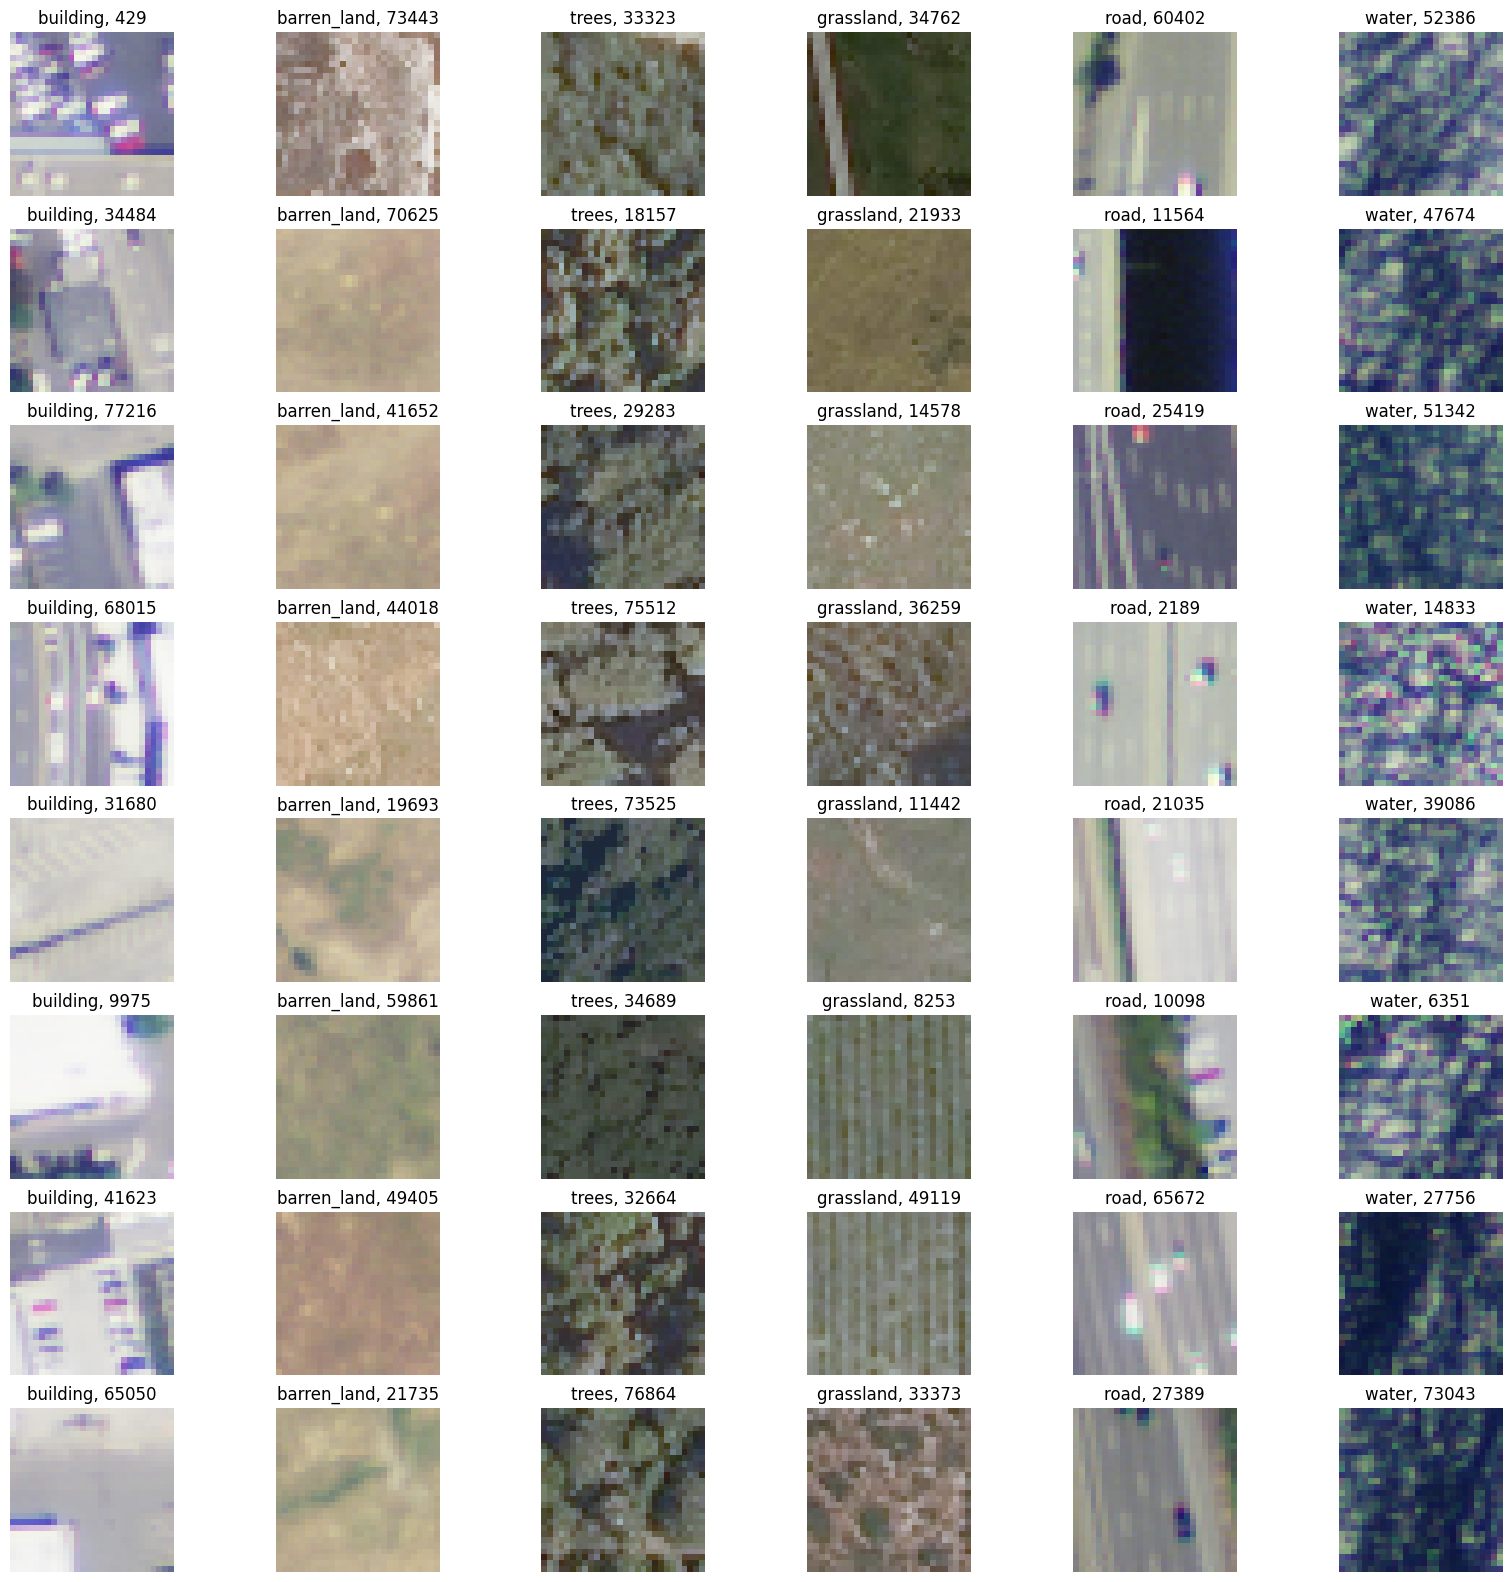

In [7]:
num_classes = len(column_names)
num_samples = 8  # number of rows to plot
sample_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_samples from this index list - make sure to avoid duplicates
    sample_idx.append(np.random.choice(np.where(class_idx.values)[0], size=num_samples, replace=False).tolist())

fig, ax = plt.subplots(num_samples, num_classes, figsize=(20,20))
for i in range(num_samples):
    for j in range(num_classes):
        data_index = sample_idx[j][i]
        ax[i,j].set_title(f"{labels[j]}, {data_index}")
        ax[i,j].axis('off')
        data = np.reshape(landcover_df.iloc[data_index].values,(-1,28,28,4))
        ax[i,j].imshow(data[0,...,:3])

plt.show()

### Create the training and test datasets

Collect equal number of samples from each class for training and testing, respectively

In [8]:
num_train = 1000
num_test = 100
train_idx = []
test_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_train and num_test values from this index list - make sure to avoid duplicates
    train_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_train, replace=False).tolist())
    test_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_test, replace=False).tolist())
print(f'number of train indices: {len(train_idx)}, number of test indices: {len(test_idx)}')


number of train indices: 6000, number of test indices: 600


&#x1F479;  _Question:_ Why use `extend`here and `append` above?

&#x1F479;  _Question:_ What is wrong with the above code?

In [9]:
# Shuffle train and test indices
train_idx = np.random.permutation(train_idx)
test_idx = np.random.permutation(test_idx)
# Extract images and labels corresponding to the selected indices
train_X = landcover_df.iloc[train_idx]
train_y = labels_df.iloc[train_idx]
test_X = landcover_df.iloc[test_idx]
test_y = labels_df.iloc[test_idx]

&#x1F479; _Question:_ Why do you want to shuffle the samples in the train and test datasets?

In [10]:
train_X

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
50356,188,188,174,77,199,191,175,84,189,185,...,151,84,174,167,155,90,189,178,162,97
11669,77,59,45,133,67,48,46,120,68,48,...,46,129,97,85,61,130,124,120,102,163
15143,178,185,163,114,176,177,154,108,139,134,...,154,104,162,164,150,109,173,180,156,112
69806,151,142,131,123,163,152,143,126,174,167,...,143,53,97,93,129,35,127,126,148,38
25974,163,135,118,189,179,156,142,198,178,152,...,121,195,178,148,131,199,196,170,155,209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15608,89,100,74,176,107,123,115,197,93,102,...,64,114,66,68,70,121,69,63,41,126
77305,156,134,125,180,148,128,122,162,148,131,...,107,164,163,147,139,181,173,161,154,189
75350,130,133,118,193,125,131,115,190,137,140,...,128,190,130,133,121,188,133,138,126,192
23194,209,197,170,186,210,198,169,181,203,195,...,132,166,152,148,131,165,150,151,128,167


## Define and intialize random classifier from scikit-learn

In [11]:
rf = RandomForestClassifier(n_estimators=100)

## Train the random forest

In [12]:
rf.fit( train_X, train_y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Check the prediction on the test set

In [13]:
rf.score(test_X, test_y)

0.925

&#x1F479;  _Task:_ Add code to plot a couple of successes and failures (i.e., where predicted labels agree/disagree with the given labels in test_y)

In [14]:
# get predictions
pred_y = rf.predict(test_X)

# convert one-hot test_y to class indices
true_labels = np.argmax(test_y.values, axis=1)
pred_labels = np.argmax(pred_y, axis=1)

# find correct and wrong predictions
correct_idx = np.where(true_labels == pred_labels)[0]
wrong_idx = np.where(true_labels != pred_labels)[0]

print(f"Number of correct predictions: {len(correct_idx)}")
print(f"Number of wrong predictions: {len(wrong_idx)}")

Number of correct predictions: 556
Number of wrong predictions: 44


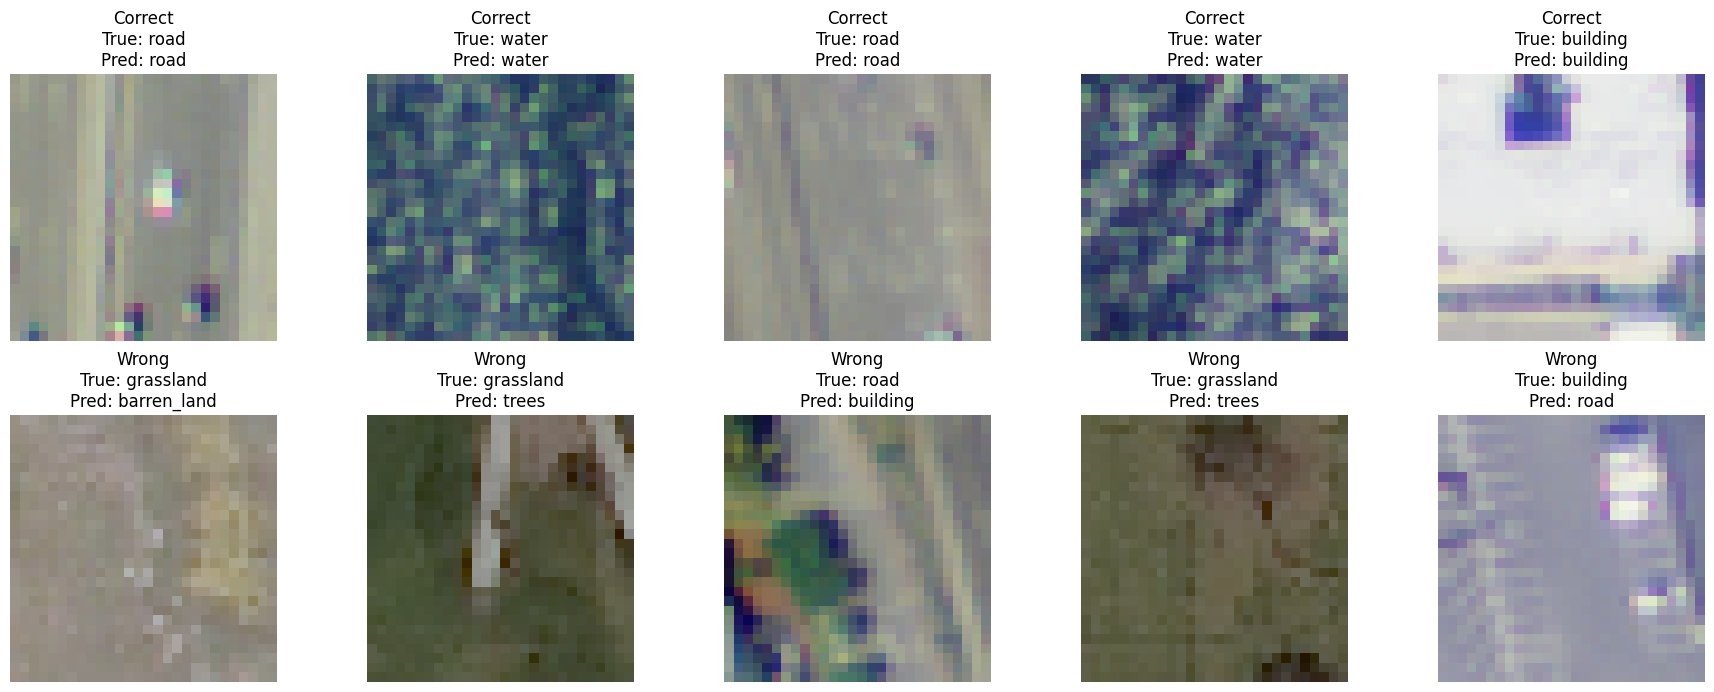

In [15]:
num_examples = 5

# Randomly select examples
correct_examples = np.random.choice(correct_idx, size=num_examples, replace=False)
wrong_examples = np.random.choice(wrong_idx, size=num_examples, replace=False)

fig, ax = plt.subplots(2, num_examples, figsize=(18, 7))

# Plot correct classifications
for i, idx in enumerate(correct_examples):
    img = np.reshape(test_X.iloc[idx].values, (28, 28, 4))
    ax[0, i].imshow(img[:, :, :3])
    ax[0, i].axis("off")
    ax[0, i].set_title(
        f"Correct\nTrue: {labels[true_labels[idx]]}\nPred: {labels[pred_labels[idx]]}"
    )

# Plot misclassifications
for i, idx in enumerate(wrong_examples):
    img = np.reshape(test_X.iloc[idx].values, (28, 28, 4))
    ax[1, i].imshow(img[:, :, :3])
    ax[1, i].axis("off")
    ax[1, i].set_title(
        f"Wrong\nTrue: {labels[true_labels[idx]]}\nPred: {labels[pred_labels[idx]]}"
    )

plt.tight_layout()
plt.show()

### 2.2: Add some code to the notebook to evaluate the classification accuracy of each class and to plot a small number of correct classification examples and a small number of misclassifications.

In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    true_labels,
    pred_labels,
    target_names=labels
))

              precision    recall  f1-score   support

    building       0.85      0.95      0.90       100
 barren_land       0.95      0.92      0.93       100
       trees       0.92      1.00      0.96       100
   grassland       0.93      0.76      0.84       100
        road       0.93      0.94      0.94       100
       water       1.00      0.99      0.99       100

    accuracy                           0.93       600
   macro avg       0.93      0.93      0.93       600
weighted avg       0.93      0.93      0.93       600



### 2.3: Inspect the 4 color channels of the data (R, G, B, and NIR). Modify the code so that it only uses the R, G, and B channels. How does this affect the classification accuracy?

In [17]:
# keep only R, G, B channels
rgb_columns = [i for i in range(train_X.shape[1]) if i % 4 != 3]

train_X_rgb = train_X.iloc[:, rgb_columns]
test_X_rgb = test_X.iloc[:, rgb_columns]

In [18]:
rf_rgb = RandomForestClassifier(n_estimators=100)
rf_rgb.fit(train_X_rgb, train_y)

baseline_score = rf.score(test_X, test_y)
rgb_score = rf_rgb.score(test_X_rgb, test_y)
print(f"All channels accuracy: {baseline_score:.4f}")
print(f"RGB-only accuracy: {rgb_score:.4f}")

All channels accuracy: 0.9250
RGB-only accuracy: 0.8900


### 2.4: Make use of only R, G, and NIR. What changes?

In [19]:

rgnir_columns = [i for i in range(train_X.shape[1]) if i % 4 != 2]

train_X_rgnir = train_X.iloc[:, rgnir_columns]
test_X_rgnir = test_X.iloc[:, rgnir_columns]

rf_rgnir = RandomForestClassifier(n_estimators=100)
rf_rgnir.fit(train_X_rgnir, train_y)

rgnir_score = rf_rgnir.score(test_X_rgnir, test_y)
print(f"R + G + NIR accuracy: {rgnir_score:.4f}")

R + G + NIR accuracy: 0.9150


### 2.5 Hyperparameter Tuning

In [20]:
# Modify n_estimators

rf_more_trees = RandomForestClassifier(n_estimators=500)
rf_more_trees.fit(train_X, train_y)

score_more_trees = rf_more_trees.score(test_X, test_y)

print(f"Baseline n_estimators=100 accuracy: {rf.score(test_X, test_y):.4f}")
print(f"Modified n_estimators=? accuracy: {score_more_trees:.4f}")

Baseline n_estimators=100 accuracy: 0.9250
Modified n_estimators=300 accuracy: 0.9217
